In [1]:
#Analise de Vendas E-commerce

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dados
df = pd.read_excel("vendas_ecommerce_2025.xlsx")

# Padronizar nomes
df.columns = df.columns.str.strip().str.replace(' ', '_').str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')


In [3]:
#Preparando dados para modelagem

In [4]:
# Feature engineering
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])
df['Data_Entrega'] = pd.to_datetime(df['Data_Entrega'])
df['Dias_Entrega'] = (df['Data_Entrega'] - df['Data_Venda']).dt.days
df['Receita_Liquida'] = (df['Preco_Unitario'] - df['Desconto']) * df['Quantidade'] + df['Frete']

# Variáveis relevantes
colunas = ['Preco_Unitario', 'Desconto', 'Frete', 'Quantidade', 'Dias_Entrega', 'Receita_Liquida']
df_model = df[colunas + ['Reembolso']].dropna()

# Separar features e target
X = df_model[colunas]
y = df_model['Reembolso']


In [5]:
#Treinando e avaliando modelo

In [6]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Avaliar
y_pred = modelo.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[95  0]
 [ 5  0]]
              precision    recall  f1-score   support

         Não       0.95      1.00      0.97        95
         Sim       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
#Visualização dos resultados

<ipython-input-8-31ea4b5d1c23>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importancia', y='Variavel', palette='viridis')


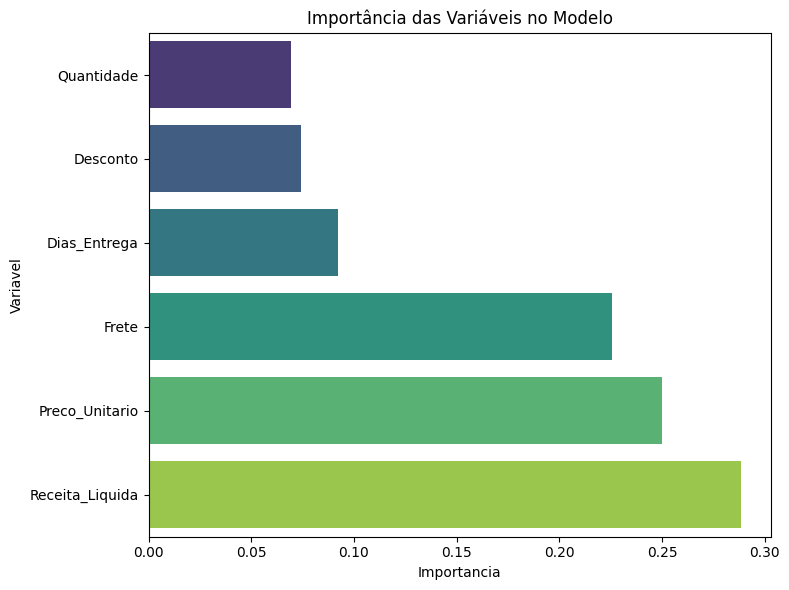

In [8]:
# Importância das variáveis
importances = modelo.feature_importances_
feat_df = pd.DataFrame({'Variavel': X.columns, 'Importancia': importances}).sort_values(by='Importancia')

# Gráfico
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x='Importancia', y='Variavel', palette='viridis')
plt.title('Importância das Variáveis no Modelo')
plt.tight_layout()
plt.show()
